# Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
file_path = '../data/raw_sweeps' # add path to data 

from utils import update_rc_params

In [2]:
from sweep import sweep_load as sl
from sweep import raster
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline

from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
from matplotlib.path import Path
from scipy.interpolate import splprep, splev

import sys
sys.path.append("../utils")
from utils import *

In [3]:
update_rc_params('talk')

# QOs at 1T

In [4]:
from matplotlib.path import Path


def plot_nD_map_field_1T(fig, ax, norm, cmap="viridis"):
    files= [2032] 
    
    ns = np.array([0.1, 0.72, 1.8, 1.8, 0.1])
    Ds = np.array([1.009, 1.065, 0.96, -0.2, -0.2])
    
    nx, ny = 301, 301
    
    verts = []
    for n, D in zip(ns, Ds):
        verts.append([n, D])
    verts = np.array(verts)
    
    Vtgs, Vbgs = calculate_gate_voltages(ns, Ds, dtg=17.25, dbg=25.5)
    
    verts_gates = []
    for Vtg, Vbg in zip(Vtgs, Vbgs):
        verts_gates.append([Vtg, Vbg])
    verts_gates = np.array(verts_gates)
    
    contact_pairs = {
        'long bot': {'indices': [1], 'norm': norm, \
                     'cmap': cmap, 'label': r'$R_{xx}$ ($\Omega$)'},
    }
    
    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            z_arr = []
            for file in files:
                data = sl.pload(file_path, file)
                mc_0 = data['measurement_config']
                md = sl.load_meta(file_path, file)
                xs = data['xs'][0] # top gate
                ys = data['xs'][1] # back gate
        
                I = data['sr830_4_X']
                I = np.pad(I, (0, len(xs) - len(I)), 'constant', constant_values=(np.nan, np.nan))
                Vxx = data[f'sr830_{ind}_X']
                Vxx = np.pad(Vxx, (0, len(xs.ravel()) - len(Vxx)), 'constant', constant_values=(np.nan, np.nan))
                zs = Vxx / I
                phase = data[f'sr830_{ind}_P']
                phase = np.pad(phase, (0, len(xs.ravel()) - len(phase)), 'constant', constant_values=(np.nan, np.nan))
                
                xs, ys = calculate_n_D(xs, ys, dtg=17.25, dbg=25.5)
                xs, ys, I = raster.pcolorize_data(I, verts, nx, ny, 1, rev_x=False, rev_y=False)
                xs, ys, zs = raster.pcolorize_data(zs, verts, nx, ny, 1, rev_x=False, rev_y=False)
                xs, ys, phase = raster.pcolorize_data(phase, verts, nx, ny, 1, rev_x=False, rev_y=False)
                z_arr.append(zs)

                finite = np.isfinite(I)
                mask = np.abs(I) < 0.5 * np.nanmax(I)
                zs_m = np.ma.array(zs, mask=mask | ~finite)
        
                plot = ax.pcolormesh(xs, ys, zs_m, norm=norm, cmap=cmap,rasterized=True, lw=0,zorder=1)
    
                zs_m = np.ma.array(np.ones(zs.shape), mask=~mask | ~finite)
                gray_cmap = colors.ListedColormap(["0.6"])
                ax.pcolormesh(xs, ys, zs_m, cmap=gray_cmap, shading="auto", rasterized=True, lw=0)

            #plot = ax.pcolormesh(xs, ys, zs, norm=norm, cmap=cmap, rasterized=True, lw=0)
            ax.set_ylabel(r'$D/\epsilon_0$ (V/nm)')
            ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')
            ax.set_ylim(0, 1.1)
    return plot


def csc_patch(fig, ax):
    # Your boundary points (close the loop by repeating the first point)
    points = np.array([[0.45, 0.92], [0.6, 0.98], [0.72, 1.05], [0.6, 1.02], \
                       [0.55, 1], [0.45, 0.92]])
    
    # Fit a smooth parametric spline
    tck, u = splprep([points[:, 0], points[:, 1]], s=0, per=True)
    u_fine = np.linspace(0, 1, 200)
    x_smooth, y_smooth = splev(u_fine, tck)
    
    # Build a matplotlib Path
    verts = np.column_stack([x_smooth, y_smooth])
    codes = [Path.MOVETO] + [Path.LINETO] * (len(verts) - 2) + [Path.CLOSEPOLY]
    
    path = Path(verts, codes)
    patch = mpatches.PathPatch(path, facecolor='none', edgecolor='white',
                               linewidth=1.5, alpha=1, zorder=5, ls="--")
    
    ax.add_patch(patch)

    return

/tmp/ipykernel_3129586/4033009557.py:49: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


['/home/aaron/Fermiology-and-the-cCSC/figs/ed-fig-qo-field.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/ed-fig-qo-field.png']

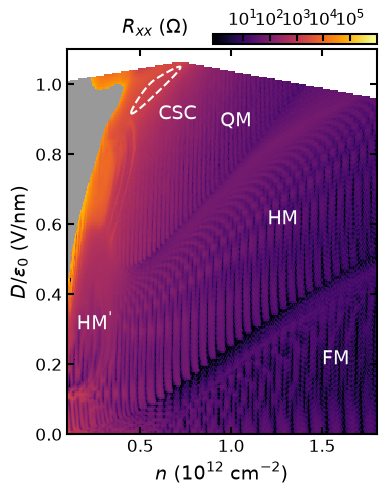

In [17]:
fig = plt.figure(figsize=(4,5))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E6)
plot = plot_nD_map_field_1T(fig, ax, norm, "inferno")
pos = ax.get_position()
cax = fig.add_axes([0.49, 0.89, 0.41, 0.02])
cb = plt.colorbar(plot, cax=cax, ticks=[10, 100, 1000, 1E4, 1E5], orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-17, x=-0.35)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')  

csc_patch(fig, ax)

 
ax.text(0.94, 0.88, "QM", color="white")
ax.text(0.6, 0.9, "CSC", color="white")

ax.text(1.2, 0.6, "HM", color="white")
ax.text(0.15, 0.3, "HM$^'$", color="white")

ax.text(1.5, 0.2, "FM", color="white")
save_fig(fig, "ed-fig-qo-field")

# QOs at 1.5T

In [6]:
def plot_nD_map_field_1p5T(fig, ax, norm, cmap="viridis"):
    files= [2033] 

    ns = np.array([0.1, 0.72, 1, 1, 0.1])
    Ds = np.array([1.009, 1.065, 0.96, 0, 0])

    nx, ny = 201, 201

    verts = []
    for n, D in zip(ns, Ds):
        verts.append([n, D])
    verts = np.array(verts)
    
    Vtgs, Vbgs = calculate_gate_voltages(ns, Ds, dtg=17.25, dbg=25.5)
    
    verts_gates = []
    for Vtg, Vbg in zip(Vtgs, Vbgs):
        verts_gates.append([Vtg, Vbg])
    verts_gates = np.array(verts_gates)
    
    contact_pairs = {
        'long bot': {'indices': [1], 'norm': norm, \
                     'cmap': cmap, 'label': r'$R_{xx}$ ($\Omega$)'},
    }
    
    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            z_arr = []
            for file in files:
                data = sl.pload(file_path, file)
                mc_0 = data['measurement_config']
                md = sl.load_meta(file_path, file)
                print("Field", md['comments'][1]['field'])
                xs = data['xs'][0] # top gate
                ys = data['xs'][1] # back gate
        
                I = data['sr830_4_X']
                I = np.pad(I, (0, len(xs) - len(I)), 'constant', constant_values=(np.nan, np.nan))
                Vxx = data[f'sr830_{ind}_X']
                Vxx = np.pad(Vxx, (0, len(xs.ravel()) - len(Vxx)), 'constant', constant_values=(np.nan, np.nan))
                zs = Vxx / I
                phase = data[f'sr830_{ind}_P']
                phase = np.pad(phase, (0, len(xs.ravel()) - len(phase)), 'constant', constant_values=(np.nan, np.nan))
                
                xs, ys = calculate_n_D(xs, ys, dtg=17.25, dbg=25.5)
                xs, ys, I = raster.pcolorize_data(I, verts, nx, ny, 1, rev_x=False, rev_y=False)
                xs, ys, zs = raster.pcolorize_data(zs, verts, nx, ny, 1, rev_x=False, rev_y=False)
                xs, ys, phase = raster.pcolorize_data(phase, verts, nx, ny, 1, rev_x=False, rev_y=False)
                z_arr.append(zs)

                finite = np.isfinite(I)
                mask = np.abs(I) < 0.5 * np.nanmax(I)
                zs_m = np.ma.array(zs, mask=mask | ~finite)
        
                plot = ax.pcolormesh(xs, ys, zs_m, norm=norm, cmap=cmap,rasterized=True, lw=0,zorder=1)
    
                zs_m = np.ma.array(np.ones(zs.shape), mask=~mask | ~finite)
                gray_cmap = colors.ListedColormap(["0.6"])
                ax.pcolormesh(xs, ys, zs_m, cmap=gray_cmap, shading="auto", rasterized=True, lw=0)
                
            #plot = ax.pcolormesh(xs, ys, zs, norm=norm, cmap=cmap, rasterized=True, lw=0)
            ax.set_ylabel(r'$D/\epsilon_0$ (V/nm)')
            ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')
            ax.set_ylim(0, 1.1)
    return plot

Field 1.500033585


/tmp/ipykernel_3129586/2588659252.py:47: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


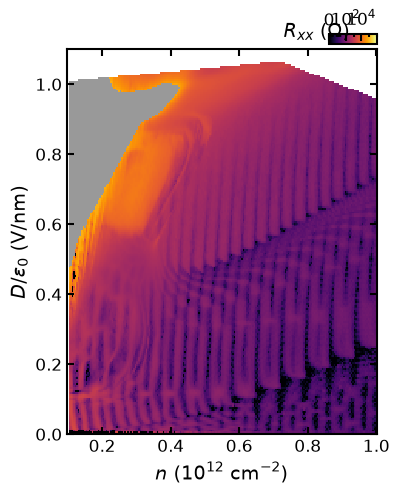

In [7]:
fig = plt.figure(figsize=(4,5))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E6)
plot = plot_nD_map_field_1p5T(fig, ax, norm, "inferno")
pos = ax.get_position()
cb_width = 0.12  
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-20, x=-0.25)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')

# QOs at 2T

In [8]:
def plot_nD_map_field_2T(fig, ax, norm, cmap="viridis"):
    files= [2031] 

    ns = np.array([0.1, 0.72, 1, 1, 0.1])
    Ds = np.array([1.009, 1.065, 0.96, 0, 0])
    
    nx, ny = 201, 201

    verts = []
    for n, D in zip(ns, Ds):
        verts.append([n, D])
    verts = np.array(verts)
    
    Vtgs, Vbgs = calculate_gate_voltages(ns, Ds, dtg=17.25, dbg=25.5)
    
    verts_gates = []
    for Vtg, Vbg in zip(Vtgs, Vbgs):
        verts_gates.append([Vtg, Vbg])
    verts_gates = np.array(verts_gates)
    
    contact_pairs = {
        'long bot': {'indices': [1], 'norm': norm, \
                     'cmap': cmap, 'label': r'$R_{xx}$ ($\Omega$)'},
    }
    
    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            z_arr = []
            for file in files:
                data = sl.pload(file_path, file)
                mc_0 = data['measurement_config']
                md = sl.load_meta(file_path, file)
                print("Field", md['comments'][1]['field'])
                xs = data['xs'][0] # top gate
                ys = data['xs'][1] # back gate
        
                I = data['sr830_4_X']
                I = np.pad(I, (0, len(xs) - len(I)), 'constant', constant_values=(np.nan, np.nan))
                Vxx = data[f'sr830_{ind}_X']
                Vxx = np.pad(Vxx, (0, len(xs.ravel()) - len(Vxx)), 'constant', constant_values=(np.nan, np.nan))
                zs = Vxx / I
                phase = data[f'sr830_{ind}_P']
                phase = np.pad(phase, (0, len(xs.ravel()) - len(phase)), 'constant', constant_values=(np.nan, np.nan))
                
                xs, ys = calculate_n_D(xs, ys, dtg=17.25, dbg=25.5)
                xs, ys, I = raster.pcolorize_data(I, verts, nx, ny, 1, rev_x=False, rev_y=False)
                xs, ys, zs = raster.pcolorize_data(zs, verts, nx, ny, 1, rev_x=False, rev_y=False)
                xs, ys, phase = raster.pcolorize_data(phase, verts, nx, ny, 1, rev_x=False, rev_y=False)
                z_arr.append(zs)

                finite = np.isfinite(I)
                mask = np.abs(I) < 0.5 * np.nanmax(I)
                zs_m = np.ma.array(zs, mask=mask | ~finite)
        
                plot = ax.pcolormesh(xs, ys, zs_m, norm=norm, cmap=cmap,rasterized=True, lw=0,zorder=1)
    
                zs_m = np.ma.array(np.ones(zs.shape), mask=~mask | ~finite)
                gray_cmap = colors.ListedColormap(["0.6"])
                ax.pcolormesh(xs, ys, zs_m, cmap=gray_cmap, shading="auto", rasterized=True, lw=0)
            ax.set_ylabel(r'$D/\epsilon_0$ (V/nm)')
            ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')
            ax.set_ylim(0, 1.1)
    return plot

Field 1.999997679


/tmp/ipykernel_3129586/3675251714.py:47: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


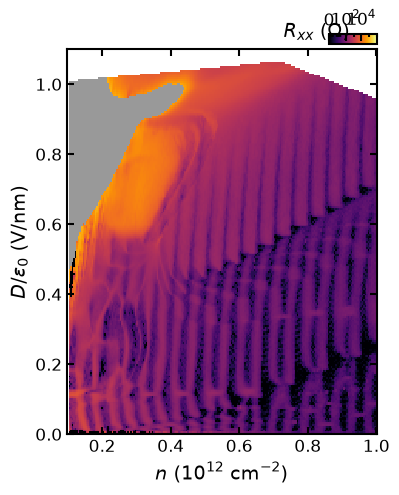

In [9]:
fig = plt.figure(figsize=(4,5))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E6)
plot = plot_nD_map_field_2T(fig, ax, norm, "inferno")
pos = ax.get_position()
cb_width = 0.12  
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-20, x=-0.25)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')

# QOs at 4T

In [10]:
def plot_nD_map_field_4T(fig, ax, norm, cmap="viridis"):
    files= [2030] 
    
    ns = np.array([0.1, 0.72, 1, 1, 0.1])
    Ds = np.array([1.009, 1.065, 0.96, 0, 0])
    
    nx, ny = 201, 201

    verts = []
    for n, D in zip(ns, Ds):
        verts.append([n, D])
    verts = np.array(verts)
    
    Vtgs, Vbgs = calculate_gate_voltages(ns, Ds, dtg=17.25, dbg=25.5)
    
    verts_gates = []
    for Vtg, Vbg in zip(Vtgs, Vbgs):
        verts_gates.append([Vtg, Vbg])
    verts_gates = np.array(verts_gates)
    
    contact_pairs = {
        'long bot': {'indices': [1], 'norm': norm, \
                     'cmap': cmap, 'label': r'$R_{xx}$ ($\Omega$)'},
    }
    
    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            z_arr = []
            for file in files:
                data = sl.pload(file_path, file)
                mc_0 = data['measurement_config']
                md = sl.load_meta(file_path, file)
                print("Field", md['comments'][1]['field'])
                xs = data['xs'][0] # top gate
                ys = data['xs'][1] # back gate
        
                I = data['sr830_4_X']
                I = np.pad(I, (0, len(xs) - len(I)), 'constant', constant_values=(np.nan, np.nan))
                Vxx = data[f'sr830_{ind}_X']
                Vxx = np.pad(Vxx, (0, len(xs.ravel()) - len(Vxx)), 'constant', constant_values=(np.nan, np.nan))
                zs = Vxx / I
                phase = data[f'sr830_{ind}_P']
                phase = np.pad(phase, (0, len(xs.ravel()) - len(phase)), 'constant', constant_values=(np.nan, np.nan))
                
                xs, ys = calculate_n_D(xs, ys, dtg=17.25, dbg=25.5)
                xs, ys, I = raster.pcolorize_data(I, verts, nx, ny, 1, rev_x=False, rev_y=False)
                xs, ys, zs = raster.pcolorize_data(zs, verts, nx, ny, 1, rev_x=False, rev_y=False)
                xs, ys, phase = raster.pcolorize_data(phase, verts, nx, ny, 1, rev_x=False, rev_y=False)
                z_arr.append(zs)

                finite = np.isfinite(I)
                mask = np.abs(I) < 0.5 * np.nanmax(I)
                zs_m = np.ma.array(zs, mask=mask | ~finite)
        
                plot = ax.pcolormesh(xs, ys, zs_m, norm=norm, cmap=cmap,rasterized=True, lw=0,zorder=1)
    
                zs_m = np.ma.array(np.ones(zs.shape), mask=~mask | ~finite)
                gray_cmap = colors.ListedColormap(["0.6"])
                ax.pcolormesh(xs, ys, zs_m, cmap=gray_cmap, shading="auto", rasterized=True, lw=0)
            ax.set_ylabel(r'$D/\epsilon_0$ (V/nm)')
            ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')
            ax.set_ylim(0, 1.1)
    return plot

Field 3.999978358


/tmp/ipykernel_3129586/3841298612.py:47: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


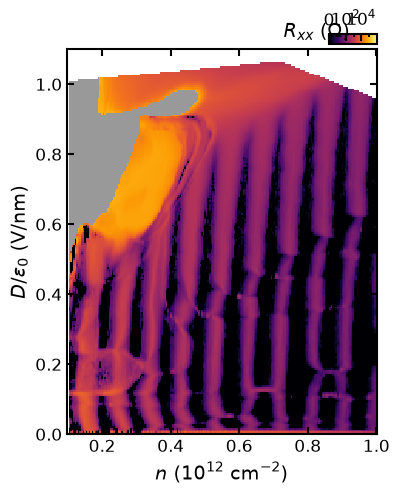

In [11]:
fig = plt.figure(figsize=(4,5))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E6)
plot = plot_nD_map_field_4T(fig, ax, norm, "inferno")
pos = ax.get_position()
cb_width = 0.12  
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-20, x=-0.25)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')

# Full figure

/tmp/ipykernel_3129586/4033009557.py:49: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


Field 1.500033585


/tmp/ipykernel_3129586/2588659252.py:47: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


Field 1.999997679


/tmp/ipykernel_3129586/3675251714.py:47: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


Field 3.999978358


/tmp/ipykernel_3129586/3841298612.py:47: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


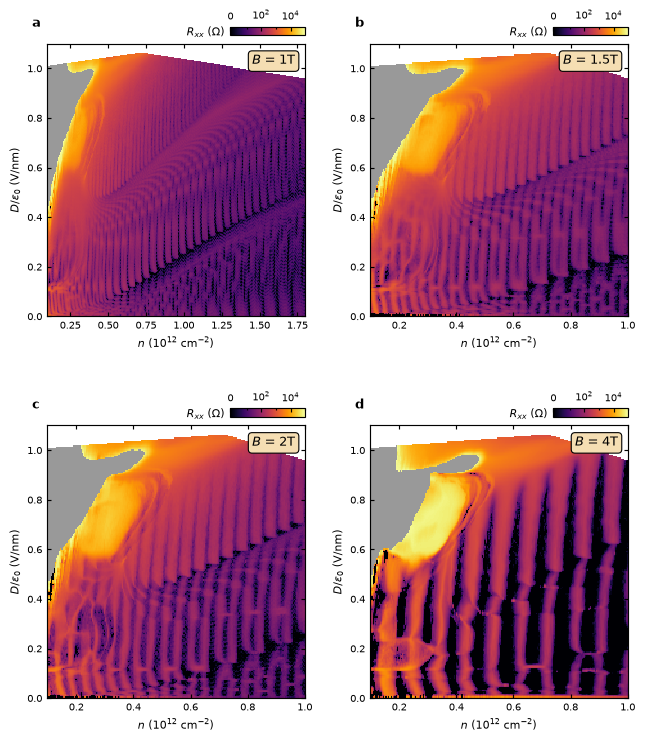

In [12]:
update_rc_params('paper')  # paper style for this final figure

fig = plt.figure(figsize=(7.5, 8.5))
gs = GridSpec(2, 2, figure=fig,   
                       width_ratios=[1,1],
                       height_ratios=[1, 1],
                       hspace=0.4, wspace=0.25)

################ Panel a ##################
ax = fig.add_subplot(gs[0, 0])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "a", fontweight='bold')

norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E5)
plot = plot_nD_map_field_1T(fig, ax, norm, "inferno")
pos = ax.get_position()
cb_width = 0.1  
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.01])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-19, x=-0.33)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')
ax.text(0.96, 0.96, "$B$ = 1T", transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='k',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                  edgecolor='k', linewidth=0.8, alpha=1))

################ Panel b ##################
ax = fig.add_subplot(gs[0, 1])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "b", fontweight='bold')

norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E5)
plot = plot_nD_map_field_1p5T(fig, ax, norm, "inferno")
pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.01])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-19, x=-0.33)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')

ax.text(0.96, 0.96, "$B$ = 1.5T", transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='k',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                  edgecolor='k', linewidth=0.8, alpha=1))
################ Panel c ##################
ax = fig.add_subplot(gs[1, 0])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "c", fontweight='bold')

norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E5)
plot = plot_nD_map_field_2T(fig, ax, norm, "inferno")
pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.01])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-19, x=-0.33)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')

ax.text(0.96, 0.96, "$B$ = 2T", transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='k',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                  edgecolor='k', linewidth=0.8, alpha=1))
################ Panel d ##################
ax = fig.add_subplot(gs[1, 1])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "d", fontweight='bold')

norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E5)
plot = plot_nD_map_field_4T(fig, ax, norm, "inferno")
pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.01])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-19, x=-0.33)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')

ax.text(0.96, 0.96, "$B$ = 4T", transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='k',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                  edgecolor='k', linewidth=0.8, alpha=1))

plt.show()
fig.savefig("ed-fig-qo-field.pdf", dpi=300, bbox_inches='tight',
            pad_inches=0.02, transparent=False)

update_rc_params('talk')  # restore presentation default

/tmp/ipykernel_3129586/4033009557.py:49: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


Field 1.500033585


/tmp/ipykernel_3129586/2588659252.py:47: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


Field 1.999997679


/tmp/ipykernel_3129586/3675251714.py:47: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


Field 3.999978358


/tmp/ipykernel_3129586/3841298612.py:47: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


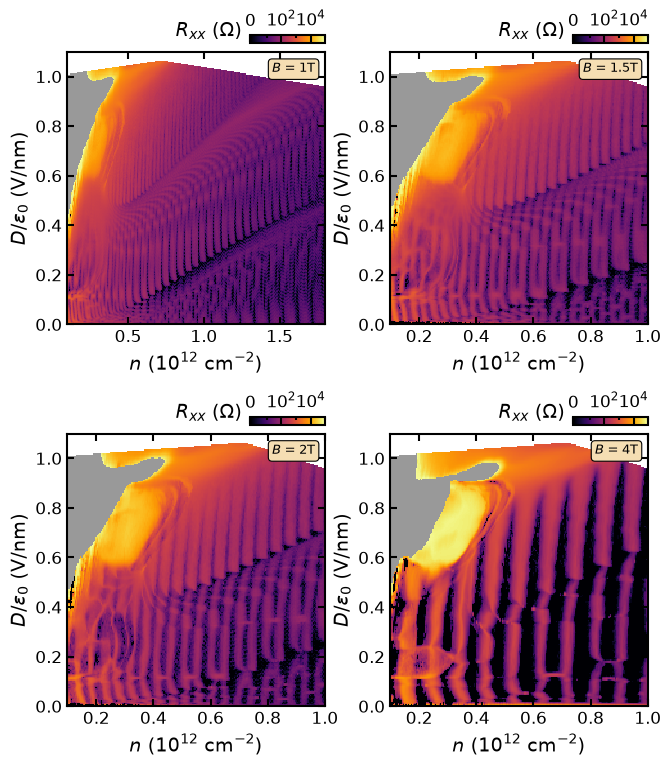

['/home/aaron/Fermiology-and-the-cCSC/figs/ed-fig-qo-field-allB.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/ed-fig-qo-field-allB.png']

In [24]:
update_rc_params('talk')  # paper style for this final figure

fig = plt.figure(figsize=(7.5, 8.5))
gs = GridSpec(2, 2, figure=fig,   
                       width_ratios=[1,1],
                       height_ratios=[1, 1],
                       hspace=0.4, wspace=0.25)

################ Panel a ##################
ax = fig.add_subplot(gs[0, 0])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
# fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "a", fontweight='bold')

norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E5)
plot = plot_nD_map_field_1T(fig, ax, norm, "inferno")
pos = ax.get_position()
cb_width = 0.1  
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.01])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-19, x=-0.55)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')
ax.text(0.96, 0.96, "$B$ = 1T", transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='k',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                  edgecolor='k', linewidth=0.8, alpha=1))

################ Panel b ##################
ax = fig.add_subplot(gs[0, 1])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
# fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "b", fontweight='bold')

norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E5)
plot = plot_nD_map_field_1p5T(fig, ax, norm, "inferno")
pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.01])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-19, x=-0.55)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')

ax.text(0.96, 0.96, "$B$ = 1.5T", transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='k',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                  edgecolor='k', linewidth=0.8, alpha=1))
################ Panel c ##################
ax = fig.add_subplot(gs[1, 0])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
# fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "c", fontweight='bold')

norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E5)
plot = plot_nD_map_field_2T(fig, ax, norm, "inferno")
pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.01])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-19, x=-0.55)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')

ax.text(0.96, 0.96, "$B$ = 2T", transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='k',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                  edgecolor='k', linewidth=0.8, alpha=1))
################ Panel d ##################
ax = fig.add_subplot(gs[1, 1])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
# fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "d", fontweight='bold')

norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E5)
plot = plot_nD_map_field_4T(fig, ax, norm, "inferno")
pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.01])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-19, x=-0.55)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')

ax.text(0.96, 0.96, "$B$ = 4T", transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='k',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                  edgecolor='k', linewidth=0.8, alpha=1))

plt.show()
fig.savefig("ed-fig-qo-field.pdf", dpi=300, bbox_inches='tight',
            pad_inches=0.02, transparent=False)

update_rc_params('talk')  # restore presentation default
save_fig(fig, "ed-fig-qo-field-allB")

Field 1.999997679


/tmp/ipykernel_3129586/2582008185.py:50: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


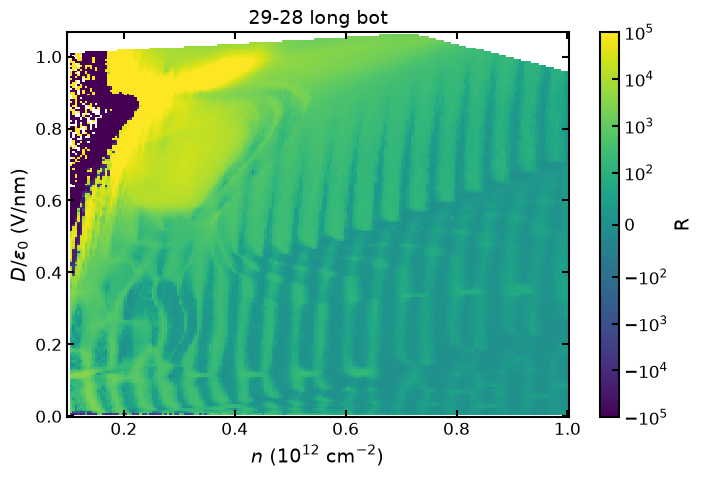

Field 1.999997679


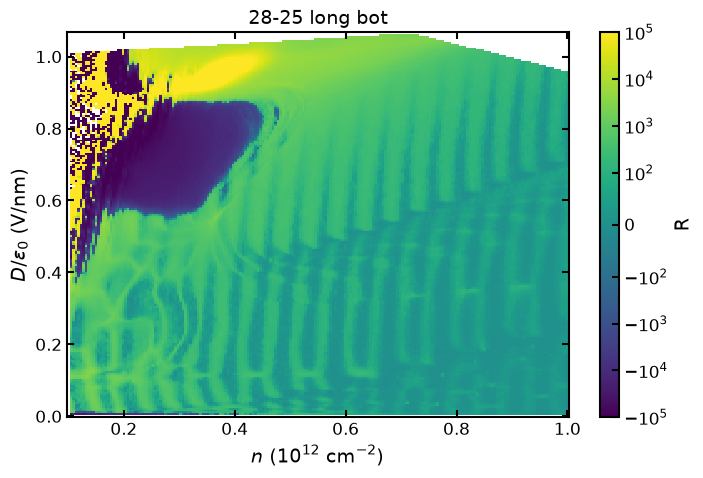

Field 1.999997679


/tmp/ipykernel_3129586/2582008185.py:50: RuntimeWarning: invalid value encountered in divide
  zs = Vxx / I


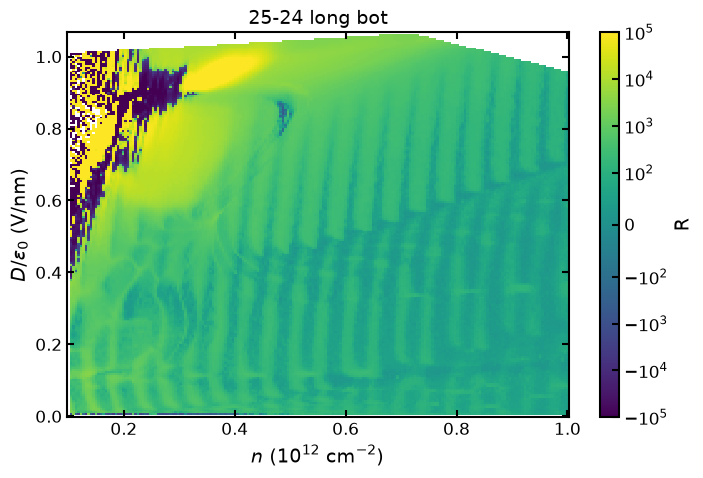

In [13]:
files= [2031] 

ns = np.array([0.1, 0.72, 1, 1, 0.1])
Ds = np.array([1.009, 1.065, 0.96, 0, 0])

nx, ny = 201, 201

verts = []
for n, D in zip(ns, Ds):
    verts.append([n, D])
verts = np.array(verts)


Vtgs, Vbgs = calculate_gate_voltages(ns, Ds, dtg=17.25, dbg=25.5)

verts_gates = []
for Vtg, Vbg in zip(Vtgs, Vbgs):
    verts_gates.append([Vtg, Vbg])
verts_gates = np.array(verts_gates)


contact_pairs = {
    'long bot': {'indices': [1, 2, 3,], 'norm': colors.SymLogNorm(linthresh=100, vmin=-1e5, vmax=1E5), 'cmap': 'viridis', 'label': r'$R_{xx}$ ($\Omega$)'},
    'long top': {'indices': [], 'norm': colors.SymLogNorm(linthresh=1e3, vmin=1e2, vmax=1E5), 'cmap': 'viridis', 'label': r'$R_{xx}$ ($\Omega$)'},
    'realhall': {'indices': [], 'norm': colors.SymLogNorm(linthresh=3E4, vmin=-1E5, vmax=1E5), 'cmap': 'RdBu_r', 'label': r'$R_{yx}$ ($\Omega$)'},
    'nl hall': {'indices': [], 'norm': colors.SymLogNorm(linthresh=3E4, vmin=-1E5, vmax=1E5), 'cmap': 'RdBu_r', 'label': r'$R_{yx}$ ($\Omega$)'},
}

for pair, options in contact_pairs.items():
    indices = options['indices']
    norm = options.get('norm', None)
    cmap = options['cmap']
    label = options['label']
    vmin = options.get('vmin', None)
    vmax = options.get('vmax', None)
    for ind in indices:
        z_arr = []
        for file in files:
            data = sl.pload(file_path, file)
            mc_0 = data['measurement_config']
            md = sl.load_meta(file_path, file)
            print("Field", md['comments'][1]['field'])
            xs = data['xs'][0] # top gate
            ys = data['xs'][1] # back gate
    
            I = data['sr830_4_X']
            I = np.pad(I, (0, len(xs) - len(I)), 'constant', constant_values=(np.nan, np.nan))
            Vxx = data[f'sr830_{ind}_X']
            Vxx = np.pad(Vxx, (0, len(xs.ravel()) - len(Vxx)), 'constant', constant_values=(np.nan, np.nan))
            zs = Vxx / I
            phase = data[f'sr830_{ind}_P']
            phase = np.pad(phase, (0, len(xs.ravel()) - len(phase)), 'constant', constant_values=(np.nan, np.nan))
            
            xs, ys = calculate_n_D(xs, ys, dtg=17.25, dbg=25.5)
            xs, ys, I = raster.pcolorize_data(I, verts, nx, ny, 1, rev_x=False, rev_y=False)
            xs, ys, zs = raster.pcolorize_data(zs, verts, nx, ny, 1, rev_x=False, rev_y=False)
            xs, ys, phase = raster.pcolorize_data(phase, verts, nx, ny, 1, rev_x=False, rev_y=False)
            z_arr.append(zs)
        
        fig, ax = plt.subplots(figsize=(5*1.618, 5))

        plot = ax.pcolormesh(xs, ys, zs, norm=norm, cmap=cmap, rasterized=True, lw=0)
        plt.colorbar(plot, ax=ax, label="R")
        # ax.set_title(f'AH contrib {mc_0[f'sr830_{ind}']} symmetric')
        ax.set_ylabel(r'$D/\epsilon_0$ (V/nm)')
        ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')
        ax.set_title(mc_0[f'sr830_{ind}'] + " " +  str(pair))

        #ax.set_xlim(0.2,0.8)
        #ax.set_ylim(0.2, 0.8)
        #ax.scatter(0.31, 0.75)
        #ax.scatter(0.44,0.99)
        plt.show()